In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import wandb

In [2]:
BATCH_SIZE = 64
NUM_CLASSES = 2
LEARNING_RATE = 0.001
EPOCHS_NUM = 20

In [3]:
run = wandb.init(
    project="classification-model-comparison",
    config={
        "batch_size": BATCH_SIZE,
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS_NUM,
        "model":"custom",
    }
)

wandb: Currently logged in as: tetiana-trachuk-kn-2021 (tetiana-trachuk-kn-2021-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [4]:
device = torch.device('cpu')
augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(size=64, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])  # Normalize
])

In [5]:
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

train_dataset_full = ImageFolder(
    root='C:/Diploma/validation_dataset',
    transform=augmentation_transforms  # Застосовуємо train_transforms
)

test_dataset_full = ImageFolder(
    root='C:/Diploma/validation_dataset',
    transform=test_transforms  
    )# Застосовуємо test_transforms

train_indices, test_indices = train_test_split(
    range(len(train_dataset_full)), 
    test_size=0.15, 
    random_state=42
)

# 6. Створюємо підмножини
train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

# 7. Створюємо завантажувачі даних
train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
# test_dataset.dataset.transform = test_transforms

# 9. Print dataset information
print(f"Classes: {train_dataset_full.classes}")
print(f"Total samples: {len(train_dataset_full)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Classes: ['not skin', 'skin']
Total samples: 15327
Training samples: 13027
Testing samples: 2300



Displaying first 10 random samples from Training Dataset:


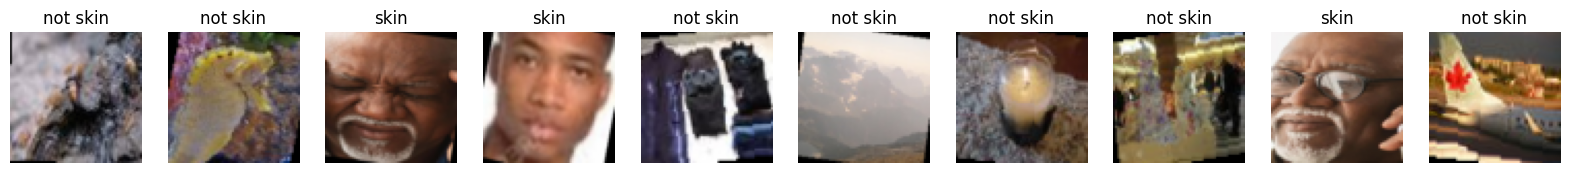

Class Labels Mapping for Training Dataset: {0: 'not skin', 1: 'skin'}

Displaying first 10 random samples from Testing Dataset:


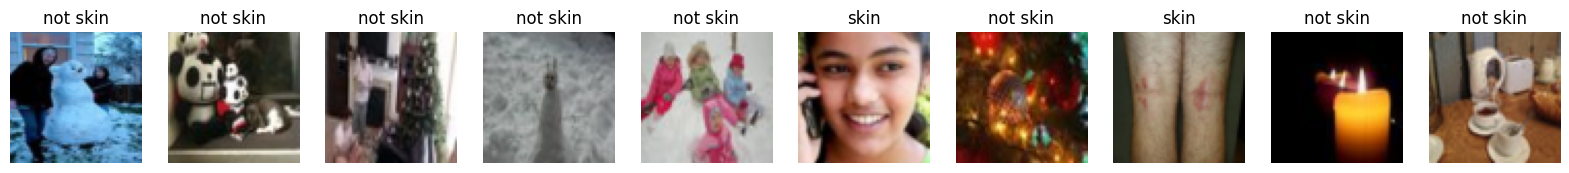

Class Labels Mapping for Testing Dataset: {0: 'not skin', 1: 'skin'}


In [6]:
import matplotlib.pyplot as plt
import random

# Display first 10 random samples from Training Dataset:
print("\nDisplaying first 10 random samples from Training Dataset:")
plt.figure(figsize=(20, 6))  # Increased figure size

# Choose 10 random samples from the training dataset
indices_train = random.sample(range(len(train_dataset)), 10)

class_labels_train = {}

for i, idx in enumerate(indices_train):
    image, label = train_dataset[idx]  
    class_labels_train[label] = train_dataset.dataset.classes[label]

    plt.subplot(2, 10, i + 1)  # Two rows, 10 columns
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Normalizing to [0, 1] range
    plt.title(class_labels_train[label])  # Display class label for each image
    plt.axis('off')

plt.show()
print("Class Labels Mapping for Training Dataset:", class_labels_train)

# Display first 10 random samples from Testing Dataset:
print("\nDisplaying first 10 random samples from Testing Dataset:")
plt.figure(figsize=(20, 6))  # Increased figure size

# Choose 10 random samples from the testing dataset
indices_test = random.sample(range(len(test_dataset)), 10)

class_labels_test = {}

for i, idx in enumerate(indices_test):
    image, label = test_dataset[idx]
    class_labels_test[label] = test_dataset.dataset.classes[label]

    plt.subplot(2, 10, i + 1)  # Two rows, 10 columns
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Normalizing to [0, 1] range
    plt.title(class_labels_test[label])  # Display class label for each image
    plt.axis('off')

plt.show()
print("Class Labels Mapping for Testing Dataset:", class_labels_test)


In [7]:
from NN_class import ConvNeuralNet

In [8]:
model = ConvNeuralNet(NUM_CLASSES)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, weight_decay = 0.005, momentum = 0.9)  

total_step = len(train_loader)

In [9]:
from utils import evaluate, train

def train_model(model, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train(model, criterion, optimizer,device,train_loader)
        eval_acc, eval_prec, eval_rec, eval_f1 = evaluate(model,device,test_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f},F1: {train_f1:.4f}")
        wandb.log({
                "Training/Loss": train_loss,
                "Training/Accuracy": train_acc,
                "Training/Precision": train_prec,
                "Training/Recall": train_rec,
                "Training/F1_Score": train_f1
            })

        print(f"Eval  - Acc: {eval_acc:.4f}, Prec: {eval_prec:.4f}, Rec: {eval_rec:.4f}, F1: {eval_f1:.4f}")
        wandb.log({
        "Evaluation/Accuracy": eval_acc,
        "Evaluation/Precision": eval_prec,
        "Evaluation/Recall": eval_rec,
        "Evaluation/F1_Score": eval_f1
    })

    return model

model = train_model(model, criterion, optimizer, EPOCHS_NUM)

Epoch [1/20]
Train - Loss: 0.1561, Acc: 0.9366, Prec: 0.9346, Rec: 0.9366,F1: 0.9352
Eval  - Acc: 0.7552, Prec: 0.9108, Rec: 0.7552, F1: 0.7923
Epoch [2/20]
Train - Loss: 0.0804, Acc: 0.9707, Prec: 0.9706, Rec: 0.9707,F1: 0.9706
Eval  - Acc: 0.8348, Prec: 0.9240, Rec: 0.8348, F1: 0.8568
Epoch [3/20]
Train - Loss: 0.0746, Acc: 0.9718, Prec: 0.9718, Rec: 0.9718,F1: 0.9718
Eval  - Acc: 0.7539, Prec: 0.9106, Rec: 0.7539, F1: 0.7912
Epoch [4/20]
Train - Loss: 0.0610, Acc: 0.9788, Prec: 0.9789, Rec: 0.9788,F1: 0.9789
Eval  - Acc: 0.8217, Prec: 0.9214, Rec: 0.8217, F1: 0.8463
Epoch [5/20]
Train - Loss: 0.0591, Acc: 0.9793, Prec: 0.9792, Rec: 0.9793,F1: 0.9793
Eval  - Acc: 0.9278, Prec: 0.9510, Rec: 0.9278, F1: 0.9335
Epoch [6/20]
Train - Loss: 0.0591, Acc: 0.9785, Prec: 0.9784, Rec: 0.9785,F1: 0.9784
Eval  - Acc: 0.9039, Prec: 0.9428, Rec: 0.9039, F1: 0.9134
Epoch [7/20]
Train - Loss: 0.0522, Acc: 0.9812, Prec: 0.9812, Rec: 0.9812,F1: 0.9812
Eval  - Acc: 0.9209, Prec: 0.9492, Rec: 0.9209, F1:

Final Accuracy on 2300 test images: 96.09 %


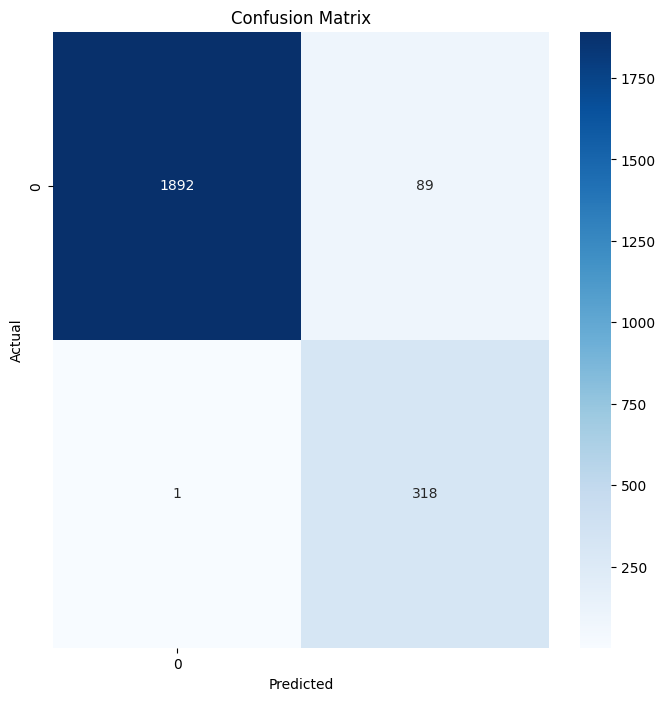

In [10]:
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from NN_class import ConvNeuralNet
import torch

model.eval()
correct = 0
total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'Final Accuracy on {len(test_dataset)} test images: {accuracy:.2f} %')


# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Логування у wandb (якщо потрібно)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.close()

In [11]:
torch.save(model.state_dict(), "../files/validation_model.pth")
print("Model saved as 'model.pth'")

Model saved as 'model.pth'


In [12]:
model = ConvNeuralNet(num_classes=2)
model.load_state_dict(torch.load("../files/validation_model.pth"))
model.eval()

C:\Users\User\AppData\Local\Temp\ipykernel_28768\4246911920.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../files/validation_model.p

ConvNeuralNet(
  (conv_layer1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_layer2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (max_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.3, inplace=False)
  (conv_layer3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_layer4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (max_pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.3, inplace=False)
  (conv_layer5): Conv